# Daily statistics from hourly ERA5 data

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit import meteo as ekm

## Load some data from the CDS

Download some ERA5 single levels data from the [Climate Data Store](https://cds.climate.copernicus.eu).
This examples uses the common surface level parameters over Europe for January 2020.

Please note that you require a CDS API key to access the CDS data. Ideally they shuold be in your ~/.cdsapirc file, if they are not you will be prompted for the credentials when executing the following cell. For more details on setting up your CDS credentials please see the [How to API page](https://cds.climate.copernicus.eu/how-to-api) in the CDS.

In [10]:
# Get some ERA5 single levels data
dataset = "reanalysis-era5-single-levels"
request = {
    "variable": [
        "total_precipitation",
        "surface_pressure",
        "2m_temperature",
        "2m_dewpoint_temperature",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "surface_net_solar_radiation",
        "surface_net_thermal_radiation",
    ],
    "product_type": "reanalysis",
    "year": "2020",
    "month": "01",
    "day": [f"{d:02d}" for d in range(1, 32)],
    "time": [f"{h:02d}:00" for h in range(24)],
    "area": [80, -20, 30, 60],  # North, West, South, East
}
era5_data_sl = ekd.from_source("cds", dataset, request)
era5_data_sl.describe()

2026-04-23 09:00:02,578 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-23 09:00:02,580 INFO Request ID is 887ac562-c62f-4c95-84eb-70be69bf7ac2
2026-04-23 09:00:02,659 INFO status has been updated to accepted
2026-04-23 09:00:12,270 INFO status has been updated to running
2026-04-23 09:06:29,403 INFO status has been updated to successful


e63af75a892d1cde0ac7356c552bbf19.grib:   0%|          | 0.00/733M [00:00<?, ?B/s]

path,/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/earthkit-data-edwardcomyn-platt/cds-retriever-c7cb5fdc9239e4d621c76309211ef1563241b2a007107e7df0d98810928d1c42.cache
size,733.1 MiB
types,"fieldlist, pandas, xarray, numpy, array"


The returned object is an `earthkit.data` object, it allows you to easily transform the object into the format
required for your workflow. The `describe` output above displays the basic information related to the data
we have downloaded. It is a `GRIB file` data object, the `types` field list the object types that it is
compatible with.

The code cell below opens the data as an `xarray.Dataset` using the earthkit engine.
The `xarray` representation allows you to explore the contents of the grib file.
Note that xarray can only represent hypercubes, but there are tools in earthkit which help you open complex
grib files as xarray. For example, in this case we set `time_dim_mode="valid_time"` which ensures that
the accumualted variables (e.g. precipitation and radiation) have the same time dimension
values as the instantaneous variables (e.g. temperature, pressure and wind).

In [11]:
era5_ds = era5_data_sl.to_xarray(time_dim_mode="valid_time")
era5_ds

<xarray.Dataset> Size: 3GB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 321)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 3kB -20.0 -19.75 -19.5 ... 59.5 59.75 60.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 384MB ...
    10v         (valid_time, latitude, longitude) float64 384MB ...
    2d          (valid_time, latitude, longitude) float64 384MB ...
    2t          (valid_time, latitude, longitude) float64 384MB ...
    sp          (valid_time, latitude, longitude) float64 384MB ...
    ssr         (valid_time, latitude, longitude) float64 384MB ...
    str         (valid_time, latitude, longitude) float64 384MB ...
    tp          (valid_time, latitude, longitude) float64 384MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Derive some additional fields

### Humidity fields with `earthkit.meteo`

We can use `earthkit.meteo` to derive some additional fields which are not available as surface variables in the ERA5 archive. The examples below calculates the Specific and Relative humidities using the surface variables we downloaded.

**Specific humidity** with dew point temperature and surface pressure

In [12]:
sh_da = ekm.thermo.specific_humidity_from_dewpoint(
    era5_ds["2d"], era5_ds["sp"]
)
# Update some metadata fields:
sh_da.attrs["standard_name"] = "specific_humidity"
sh_da.attrs["long_name"] = "Specific humidity near the surface"
sh_da = sh_da.rename("q2m")
# Add to our existing dataset:
era5_ds["2q"] = sh_da

**Relative humidity** with air temperature and dew point temperature

In [13]:
rh_da = ekm.thermo.relative_humidity_from_dewpoint(
    era5_ds["2t"], era5_ds["2d"]
)
# Update some metadata fields:
rh_da.attrs["standard_name"] = "relative_humidity"
rh_da.attrs["long_name"] = "Relative humidity near the surface"
rh_da = rh_da.rename("r2m")
# Add to our existing dataset:
era5_ds["2r"] = rh_da
era5_ds

<xarray.Dataset> Size: 4GB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 321)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 3kB -20.0 -19.75 -19.5 ... 59.5 59.75 60.0
Data variables:
    10u         (valid_time, latitude, longitude) float64 384MB ...
    10v         (valid_time, latitude, longitude) float64 384MB ...
    2d          (valid_time, latitude, longitude) float64 384MB 240.0 ... 270.0
    2t          (valid_time, latitude, longitude) float64 384MB 244.7 ... 273.9
    sp          (valid_time, latitude, longitude) float64 384MB 9.334e+04 ......
    ssr         (valid_time, latitude, longitude) float64 384MB ...
    str         (valid_time, latitude, longitude) float64 384MB ...
    tp          (valid_time, latitude, longitude) float64 384MB ...
    2q          (valid_time, latitude, longitude) float64 384MB 0.0002502 ......
    2r          (valid_time, latitude, longitude) float64 384MB 64.1 ... 74.7
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

### Convert accumulated radiation to a rate value with `earthkit-transforms`

The radiation fields produced by ECMWF are traditionally stored as accumulated fields,
i.e. units = J m⁻².
To convert these to the more commonly used rate variables, i.e. units = W m⁻²,
we make use of Earthkit transform's accumulation_to_rate function.

Please be aware that mean rate variables are available in the ERA5 archive,
and users are encouraged to use them.

In [18]:
tp_rate = ekt.temporal.accumulation_to_rate(era5_ds["tp"])
ssr_rate = ekt.temporal.accumulation_to_rate(era5_ds["ssr"])
str_rate = ekt.temporal.accumulation_to_rate(era5_ds["str"])
# Add to our existing dataset:
era5_ds["tp_rate"] = tp_rate
era5_ds["ssr_rate"] = ssr_rate
era5_ds["str_rate"] = str_rate

era5_ds

<xarray.Dataset> Size: 5GB
Dimensions:     (valid_time: 744, latitude: 201, longitude: 321)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:...
  * latitude    (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 3kB -20.0 -19.75 -19.5 ... 59.5 59.75 60.0
Data variables: (12/13)
    10u         (valid_time, latitude, longitude) float64 384MB ...
    10v         (valid_time, latitude, longitude) float64 384MB ...
    2d          (valid_time, latitude, longitude) float64 384MB 240.0 ... 270.0
    2t          (valid_time, latitude, longitude) float64 384MB 244.7 ... 273.9
    sp          (valid_time, latitude, longitude) float64 384MB 9.334e+04 ......
    ssr         (valid_time, latitude, longitude) float64 384MB 3.6e-12 ... 3...
    ...          ...
    tp          (valid_time, latitude, longitude) float64 384MB 9.537e-07 ......
    2q          (valid_time, latitude, longitude) float64 384MB 0.0002502 ......
    2r          (valid_time, latitude, longitude) float64 384MB 64.1 ... 74.7
    ssr_rate    (valid_time, latitude, longitude) float64 384MB 1e-15 ... 1e-15
    str_rate    (valid_time, latitude, longitude) float64 384MB -12.05 ... -7...
    tp_rate     (valid_time, latitude, longitude) float64 384MB 2.649e-10 ......
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Calculate the monthly mean of the daily maximum

We can use `earthkit.transforms` to calculate monthly and daily statistics of the variables in the dataset.

We will calculate the monthly mean of the daily maximum of all the variables.
As we have a single month of data, this will reduce to a single time step,
very convenient for our subsequent plotting.
Note that this calculation may not be useful for all the variables in our dataset,
we just demonstrate the simplicity of performing the calculations in batch.

In [19]:
era5_ds_daily_max = ekt.temporal.daily_max(era5_ds)
era5_ds_monthly_mean_daily_max = ekt.temporal.monthly_mean(era5_ds_daily_max)
era5_ds_monthly_mean_daily_max

<xarray.Dataset> Size: 7MB
Dimensions:     (valid_time: 1, latitude: 201, longitude: 321)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2020-01-01
  * latitude    (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 30.5 30.25 30.0
  * longitude   (longitude) float64 3kB -20.0 -19.75 -19.5 ... 59.5 59.75 60.0
Data variables: (12/13)
    10u         (valid_time, latitude, longitude) float64 516kB 0.8637 ... 2.989
    10v         (valid_time, latitude, longitude) float64 516kB -0.8687 ... 2...
    2d          (valid_time, latitude, longitude) float64 516kB 242.5 ... 276.3
    2t          (valid_time, latitude, longitude) float64 516kB 245.4 ... 285.1
    sp          (valid_time, latitude, longitude) float64 516kB 9.471e+04 ......
    ssr         (valid_time, latitude, longitude) float64 516kB 3.6e-12 ... 1...
    ...          ...
    tp          (valid_time, latitude, longitude) float64 516kB 7.594e-05 ......
    2q          (valid_time, latitude, longitude) float64 516kB 0.0003502 ......
    2r          (valid_time, latitude, longitude) float64 516kB 82.41 ... 84.13
    ssr_rate    (valid_time, latitude, longitude) float64 516kB 1e-15 ... 489.5
    str_rate    (valid_time, latitude, longitude) float64 516kB 5.085 ... -43.81
    tp_rate     (valid_time, latitude, longitude) float64 516kB 2.109e-08 ......
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

## Plot the output

Something about `earthkit-plots`

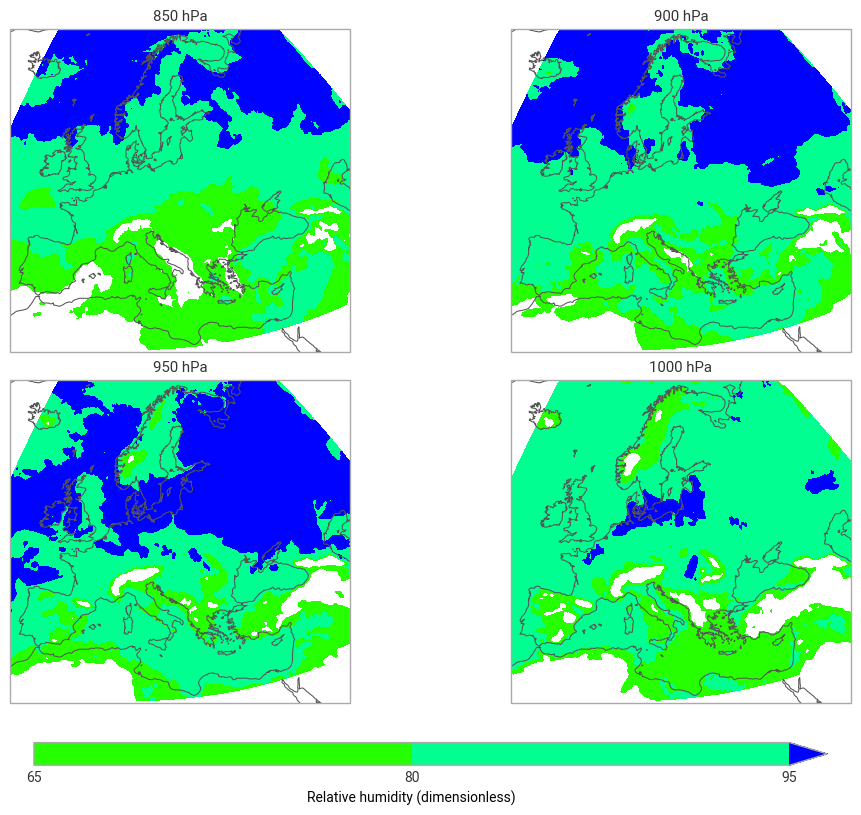

In [32]:
ekp.quickplot(
    era5_ds_monthly_mean_daily_max[["r"]], domain="europe",
    title="{level} hPa"
)